In [1]:
from google.colab import files
import pandas as pd

print("📤 Please upload your CSV file...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("✅ Dataset Loaded!")
print(f"Shape: {df.shape}")
df.head()

📤 Please upload your CSV file...


Saving customer_support_text_classification.csv to customer_support_text_classification (2).csv
✅ Dataset Loaded!
Shape: (1500, 6)


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [2]:
# Install compatible versions
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud -q
!pip install tensorflow==2.19.0 -q

import nltk
nltk.download('stopwords')
nltk.download('punkt')

print("✅ All libraries installed successfully!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
✅ All libraries installed successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
# Install all required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud -q

# Install compatible TensorFlow version
!pip install tensorflow==2.20.0 -q

import nltk
nltk.download('stopwords')
nltk.download('punkt')

import tensorflow as tf
print("TensorFlow Version:", tf.__version__)

print("✅ All libraries installed successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


TensorFlow Version: 2.20.0
✅ All libraries installed successfully!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

print("=== TASK 1: Dataset Understanding ===")
print(f"Number of records: {df.shape[0]}")
print(f"Columns: {df.columns.tolist()}\n")

print("Target Classes:")
print(df['sentiment_label'].value_counts())
print("\nClass Distribution (%):")
print(round(df['sentiment_label'].value_counts(normalize=True)*100, 2))

print(f"\nAverage word count: {df['word_count'].mean():.2f}")

print("\nSample Messages:")
for i in range(3):
    print(f"{i+1}. {df['customer_message'].iloc[i]}")

=== TASK 1: Dataset Understanding ===
Number of records: 1500
Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Target Classes:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Class Distribution (%):
sentiment_label
neutral     34.93
negative    33.13
positive    31.93
Name: proportion, dtype: float64

Average word count: 12.72

Sample Messages:
1. I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
2. I need information about the payment process.
3. The refund process was fast and convenient. I appreciate the quick response.


/tmp/ipykernel_16661/1200896359.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment_label', palette='viridis')


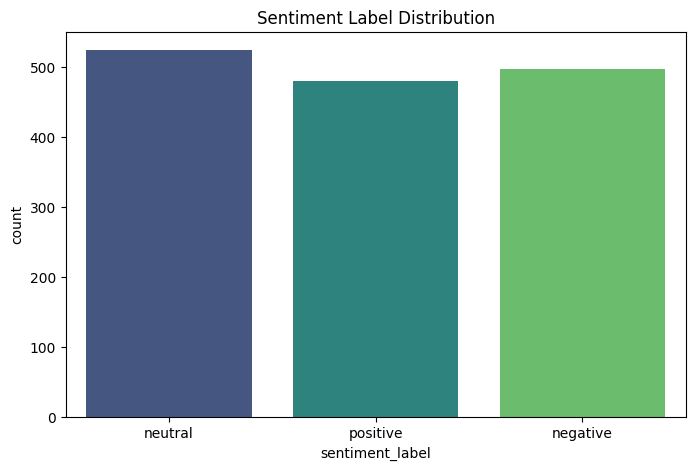

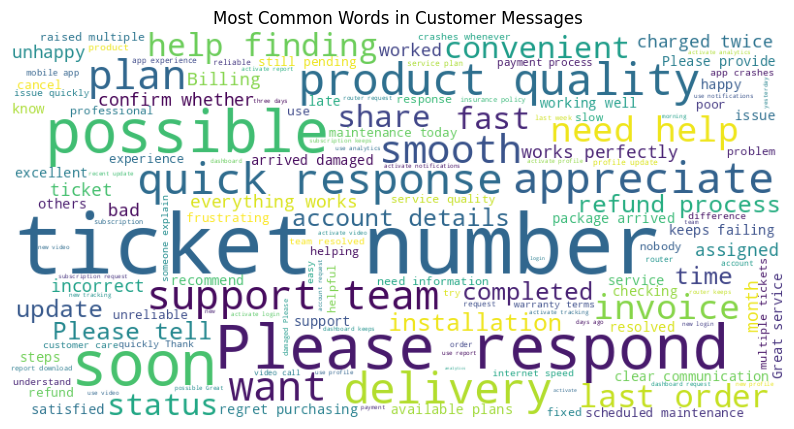

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sentiment_label', palette='viridis')
plt.title('Sentiment Label Distribution')
plt.savefig('class_distribution.png')
plt.show()

text = ' '.join(df['customer_message'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Most Common Words in Customer Messages')
plt.savefig('wordcloud.png')
plt.show()

In [6]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['cleaned_message'] = df['customer_message'].apply(preprocess_text)

print("✅ Text Preprocessing Completed!")
print("Original :", df['customer_message'].iloc[0])
print("Cleaned  :", df['cleaned_message'].iloc[0])

✅ Text Preprocessing Completed!
Original : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
Cleaned  : need information payment process ticket number please respond soon possible


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("🔄 TF-IDF Vectorization...")
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['cleaned_message'])
print(f"✅ TF-IDF Shape: {X_tfidf.shape}")

print("\n🔄 Tokenizer + Padding...")
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_message'])

sequences = tokenizer.texts_to_sequences(df['cleaned_message'])
max_len = 50
X_seq = pad_sequences(sequences, maxlen=max_len, padding='post')

print(f"✅ Padded Sequences Shape: {X_seq.shape}")
print("✅ Vectorization Completed!")

🔄 TF-IDF Vectorization...
✅ TF-IDF Shape: (1500, 146)

🔄 Tokenizer + Padding...
✅ Padded Sequences Shape: (1500, 50)
✅ Vectorization Completed!


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X = X_tfidf
y = df['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

print("=== BASELINE MODEL RESULTS ===")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

=== BASELINE MODEL RESULTS ===
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Accuracy: 1.0000


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(df['sentiment_label'])

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=max_len),
    LSTM(64, dropout=0.3, recurrent_dropout=0.3),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("🚀 Training LSTM Model...")
history = model.fit(X_train_seq, y_train_seq,
                    epochs=8,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

loss, acc = model.evaluate(X_test_seq, y_test_seq)
print(f"\n🎉 LSTM Test Accuracy: {acc:.4f}")

model.save('lstm_model.h5')
print("✅ Model Saved!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


🚀 Training LSTM Model...
Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - accuracy: 0.3333 - loss: 1.1005 - val_accuracy: 0.3375 - val_loss: 1.0997
Epoch 2/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.3448 - loss: 1.1007 - val_accuracy: 0.3042 - val_loss: 1.0996
Epoch 3/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - accuracy: 0.3385 - loss: 1.1005 - val_accuracy: 0.3375 - val_loss: 1.1001
Epoch 4/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.3521 - loss: 1.0970 - val_accuracy: 0.3375 - val_loss: 1.1017
Epoch 5/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.3583 - loss: 1.0997 - val_accuracy: 0.3375 - val_loss: 1.0977
Epoch 6/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 341ms/step - accuracy: 0.3521 - loss: 1.1016 - val_accuracy: 0.3375 - val_loss: 1.1016
Epoch 7/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.3323 - loss: 1.0990 - val_accuracy: 0.3375 - val_loss: 1.0999
Epoch 8/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3552 - loss: 1.0990 - 


🎉 LSTM Test Accuracy: 0.3500
✅ Model Saved!


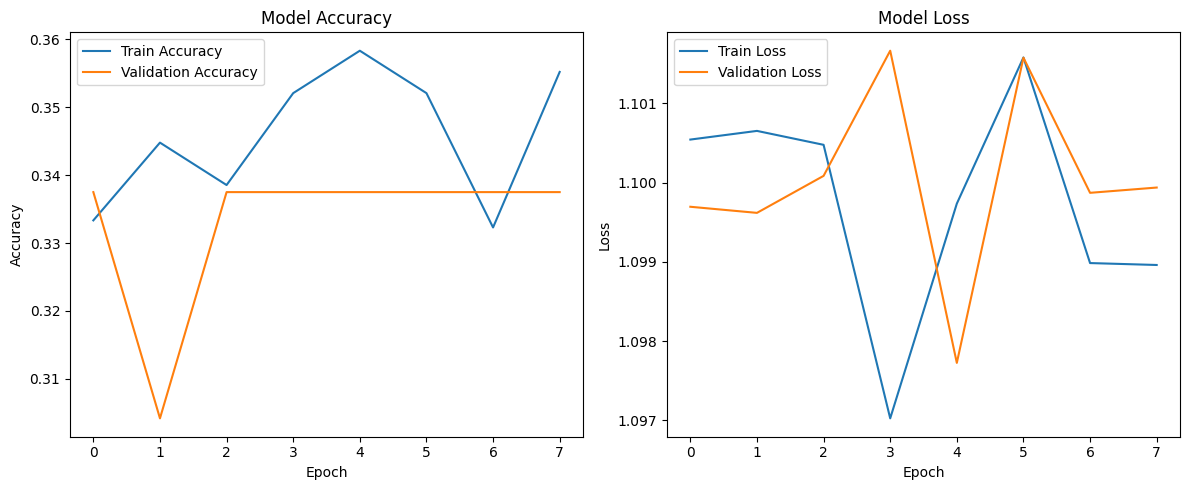

In [11]:
# Plot Training History
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

## Task 6: Attention and Transformer Reflection

**Why RNNs struggle with long-term dependencies?**  
They suffer from the **vanishing gradient problem** — making it difficult to learn from earlier parts of long sequences.

**How LSTMs help?**  
LSTMs use **gating mechanisms** (Forget, Input, Output gates) to better control what information to keep or discard over long sequences.

**What does Attention solve?**  
It allows the model to **dynamically focus** on relevant parts of the input at every step, instead of relying on a single compressed vector.

**Why Transformers are important?**  
They use **Self-Attention**, are highly parallelizable, and capture long-range dependencies efficiently. They are the backbone of modern NLP and Generative AI (like GPT, BERT, etc.).

In [ ]:
from google.colab import files

files.download('class_distribution.png')
files.download('wordcloud.png')
files.download('lstm_model.h5')

print("✅ All result files downloaded!")